# 定義元素變異
表示法：定義每個企業創新策略元素為一個基因。  
初始群體生成：創建一個包含多個個體的初始群體，每個個體是一組隨機選擇的策略元素組合。  
適應度函數：設計一個適應度函數來評估每個個體的優良程度。可以根據一些具體指標（如市場反應、投資回報率等）來評估策略組合的優劣。  
選擇：根據適應度函數選擇一些優良個體進行交配和變異。  
交叉：對選擇的個體進行交叉操作，生成新的個體。  
變異：對一些個體進行變異操作，以引入多樣性。  
迭代：重複以上步驟多次，直到找到最優的策略組合。

使用期交所的歷史台指期資料  
存入的檔案日期當天的，漲跌是由前一天的新聞判斷  
這個方法只有判斷 yes no 沒有 unknown  

檔案說明：  
存在 out_element  


In [48]:
import os
import textwrap
import math
import pandas as pd
import numpy as np

from datetime import datetime
from dateutil.relativedelta import relativedelta

import google.generativeai as genai
from langchain.schema.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory

from IPython.display import display
from IPython.display import Markdown

model = 'gemini-1.5-flash'
temperature = 1
top_p = 0.9
seed = 0

def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatGoogleGenerativeAI(
                google_api_key = os.getenv('GEMINI_API_KEY'),
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                safety_settings={
                        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
                
            })

In [49]:
# 定義策略元素字典，每個元素對應一個代號
elements = {
    "E1": "企業創新策略：企業創新的核心主題，涵蓋所有驅動企業增長和競爭力提升的策略。",
    "E2": "滿足客戶需求：企業創新的首要驅動力，能否滿足客戶需求直接影響創新成敗。",
    "E3": "吸引投資者關注：投資者的關注和信心能為企業提供必要的資金和支持，是創新成功的重要標誌。",
    "E4": "市場需求與趨勢：市場需求的變化和行業趨勢是影響企業股票表現的關鍵因素，企業需適應並預測市場變化。",
    "E5": "財務表現：穩定且增長的收入、利潤和現金流是吸引投資者的主要因素，能增加投資者信心，推動股價上漲。",
    "E6": "技術進步與研發投入：持續的技術創新和研發投入能提高企業競爭力和市場地位，促進企業長期增長。",
    "E7": "經營效率：有效的經營管理能提高企業盈利能力，進而提升股票價值。",
    "E8": "品牌聲譽與市場認可度：良好的品牌聲譽和市場認可度能增加企業產品的市場需求，促進銷售增長。",
    "E9": "政策與法規支持：政府政策和法規對行業的支持或限制會直接影響企業的發展前景和市場表現。",
    "E10": "競爭優勢與市場份額：企業在市場中的競爭優勢和市場份額的提升能增強其市場地位，吸引更多投資者。",
    "E11": "全球化與國際市場拓展：進入國際市場並擴展全球業務能增加企業的市場規模和收入來源。",
    "E12": "風險管理與應對能力：有效的風險管理策略和應對能力能降低企業運營風險，提高投資者信心。",
    "E13": "人才管理與員工激勵：擁有高素質的人才和有效的激勵機制能提升企業創新能力和生產效率。",
    "E14": "合作夥伴關係：與其他企業建立戰略合作夥伴關係能共享資源和技術，提升市場競爭力。",
    "E15": "市場營銷與品牌推廣：有效的市場營銷和品牌推廣策略能提高企業知名度和市場需求。",
    "E16": "客戶服務與滿意度：高品質的客戶服務和較高的客戶滿意度能提高客戶忠誠度和口碑。",
    "E17": "供應鏈管理：高效的供應鏈管理能確保產品質量和交付效率，降低成本。",
    "E18": "產品多樣化與創新：不斷推出創新產品和服務能滿足不同市場需求，提升企業競爭力。",
    "E19": "環保與可持續發展：採用環保和可持續發展策略能提高企業形象，吸引關注可持續投資的投資者。",
    "E20": "數位轉型與科技應用：積極進行數位轉型和應用新技術能提高運營效率和市場響應速度。",
    "E21": "競爭對手分析與市場擴展：深入分析競爭對手的策略和行動，制定有效的市場擴展和新市場進入策略。",
    "E22": "資本結構、財務穩定性與資金籌措：健康的資本結構和財務穩定性以及有效的資金籌措能增強企業的抗風險能力和持續發展能力。",
    "E23": "客戶數據分析：利用大數據和數據分析技術深入了解客戶需求，提升產品和服務的針對性。",
    "E24": "知識產權保護：有效保護企業的知識產權能防止競爭對手抄襲，提高創新成果的市場價值。",
    "E25": "企業文化與價值觀：建立積極向上的企業文化和價值觀能吸引優秀人才，提升企業凝聚力和創新力。",
    "E26": "股東回報與分紅政策：穩定的股東回報和合理的分紅政策能吸引長期投資者。",
    "E27": "社會責任與公益活動：積極參與社會責任和公益活動能提升企業形象，獲得更多社會支持。",
    "E28": "成本控制: 有效的成本控制能提高企業獲利能力。",
}

In [50]:
# 台積電的{tech_prompt}
# 以下是新聞標題：『{text_news}』
# 請一步一步的用上面的資訊思考台積電隔天開盤到收盤的可能漲跌，如果你認為台積電會上漲請回答#yes，如果你認為台積電會下跌請回答#no

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no
# 你的理由: 說明你的判斷理由


In [51]:
# 以下是台積電的新聞標題：『{text_news}』
# 請一步一步的用上面的資訊思考台積電隔天開盤到收盤的可能漲跌，如果你認為台積電會上漲請回答#yes，如果你認為台積電會下跌請回答#no

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no
# 你的理由: 說明你的判斷理由

In [52]:
# 透過前一天的新聞判斷今日的股市走勢
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def call_tech(d):
    path_his_tech = os.path.join(os.path.abspath(os.path.dirname(os.getcwd())), 'history_data', 'tw', 'stock_price', '2330tech.csv')
    # 讀取CSV檔案
    df = pd.read_csv(path_his_tech, encoding='utf-8')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
    df = df[(d == df['Date'])]

    # 計算5日均線
    ma5 = "上漲" if df['MA5'].values[0] < df["Close"].values[0] else "下跌"
    ma10 = "之上" if df['MA10'].values[0] < df["Close"].values[0] else "之下"
    ma20 = "之上" if df['MA20'].values[0] < df["Close"].values[0] else "之下"
    ema12 = "之上" if df['EMA12'].values[0] < df["Close"].values[0] else "之下"
    ema26 = "之上" if df['EMA26'].values[0] < df["Close"].values[0] else "之下"
    dif_macd = round(df['DIF'].values[0] - df['MACD'].values[0],3) 

    elements = [
        f"五日均線為{ma5}趨勢",
        # f"收盤後股價在5日均線{ma5},10日均線{ma10},20日均線{ma20}",
        # f"RSI值為{round(df['RSI'].values[0], 3)}",
        # f"MACD指標值, DIF-MACD值:{dif_macd}",
        # f"KD值為,k:{round(df['K'].values[0],1)},d:{round(df['D'].values[0], 1)}",
        # f'開盤{df["開盤指數"].values[0]}，最高{df["最高指數"].values[0]}，最低{df["Low"].values[0]}，收盤{df["Close"].values[0]}',
        # f"收盤後股價在12日加權平均線{ema12},26日加權平均線{ema26}",
    ]

    prompt = ""
    for i in range(len(elements)):
        prompt += f"{str(i+1)} : {elements[i]}\n"
    return prompt

def analyze_market(st, et, prompt):
    stock_id = '2330'
    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/stock_price/2330twse.csv"

    # 讀取CSV檔案
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['Date']) & (df_price_his['Date'] <= et)]

    idx = 1
    batch_size = 200
    output_data = {}  # 使用字典來存儲每一天的輸出數據

    while idx < len(df_price_his):
        batch = []
        for i in range(batch_size):
            if idx + i >= len(df_price_his):
                break
            
            # 取得前一日日期和新聞標題
            news_date = df_price_his.iloc[idx + i]['Date'] - timedelta(days=1)
            path_news_file = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"
            text_news = ""
            with open(path_news_file, 'r', encoding='utf-8') as f:
                news_data = json.load(f)
                text_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
            
            # 取得前一個交易日的技術指標
            last_date = df_price_his.iloc[idx + i - 1]['Date']
            tech_prompt = call_tech(last_date)
            # 當日股價的技術指標如下： 『{tech_prompt}』

            # 設置初始消息列表，包括 SystemMessage 和第一個 HumanMessage
            messages = [
                ("system", "你是一個厲害的股市操盤手，專長是當日沖消"),
                ("human",
f"""
以下是台積電的新聞標題：『{text_news}』
請一步一步的用上面的資訊思考台積電隔天開盤到收盤的可能漲跌，如果你認為台積電會上漲請回答#yes，如果你認為台積電會下跌請回答#no

用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
判斷結果: #yes/#no
你的理由: 說明你的判斷理由
""")
            ]
            batch.append(messages)

        res = llm.batch(batch)

        for i in range(len(res)):
            # 被預測的日期
            date_str = df_price_his.iloc[idx + i]['Date'].strftime('%Y%m%d')
            output_data[date_str] = {
                "token": res[i].usage_metadata,
                "raw_data": res[i].content,
            }

        # time.sleep(60)
        idx += batch_size

    # 將所有輸出數據寫入到同一個json檔案中
    data = {
        "model": model,
        "temperature": temperature,
        "top_p": top_p,
        "seed": seed,
        "prompt": prompt,
        "output_data": output_data,
    }
    
    return data

In [53]:
def save_data(folder_path, data):
    count = 1
    while True:
        if os.path.exists(folder_path + str(count) + ".json"):
            count += 1
            continue
        else:
            out_file = folder_path + str(count) + ".json"
            break
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    
    return out_file

## 評分

In [54]:
import pandas as pd
import json
import os

def eval(output_data):
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    token_input = 0
    token_output = 0

    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/stock_price/2330tech.csv"
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')

    for date_str, result in output_data.items():
        token_input += result["token"]["input_tokens"]
        token_output += result["token"]["output_tokens"]
        sig_str = result["raw_data"].split("你的理由")[0]
        sig = 0

        if "unknown" in sig_str:
            sig = 0
        elif "yes" in sig_str:
            sig = 1
        elif "no" in sig_str:
            sig = -1
        else:
            sig = 0

        df_price = df_price_his[df_price_his['Date'] == pd.to_datetime(date_str, format='%Y%m%d')]

        if df_price.empty:
            continue

        rtn = (df_price.iloc[0]['Close'] - df_price.iloc[0]['Open']) / df_price.iloc[0]['Open']

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
        'ask_count': len(output_data),
        'token_input': token_input,
        'token_output': token_output,
    }

    return result

## 第二種評分方式

In [78]:
import pandas as pd
import json
import os

def eval2(output_data):
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    token_input = 0
    token_output = 0

    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/stock_price/2330tech.csv"
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')


    for date_str, result in output_data.items():
        token_input += result["token"]["input_tokens"]
        token_output += result["token"]["output_tokens"]
        sig_str = result["raw_data"].split("你的理由")[0]
        sig = 0

        df_price = df_price_his[df_price_his['Date'] == pd.to_datetime(date_str, format='%Y%m%d')]
        last_date = df_price_his.iloc[df_price.index[0]-1]
        sig_tech = 0
        if last_date['MA5'] < last_date["Close"]:
            sig_tech = 1
        else:
            sig_tech = -1

        if df_price.empty:
            continue
        
        if sig_tech == 1:
            if "yes" in sig_str:
                sig = 1
            else:
                sig = 0
        elif sig_tech == -1:
            if "no" in sig_str:
                sig = -1
            else:
                sig = 0
        print(sig_tech, sig)

        rtn = (df_price.iloc[0]['Close'] - df_price.iloc[0]['Open']) / df_price.iloc[0]['Open']

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
        'ask_count': len(output_data),
        'token_input': token_input,
        'token_output': token_output,
    }

    return result

# Training
遺傳演算法

In [ ]:
import json
import random
from datetime import datetime

individual_score = {}
ask_count = 0
start_day = datetime(2024, 4, 1)
end_day = datetime(2024, 6, 30)
out_folder = "out_element/2330_0401_0630/"
state_file= out_folder + '/state.json'
results_file= out_folder + '/generation_results.json'
print("Start, ask_count:", ask_count, "individual_score:", individual_score, "第一次跑的話請確認state是空的")

# 儲存-----------------------------------------
# 儲存狀態
def save_state(filename, state, message):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    print("Save state", message, state)
    with open(filename, 'w') as f:
        json.dump(state, f)

# 載入狀態
def load_state(filename):
    try:
        with open(filename, 'r') as f:
            content = f.read().strip()
            if not content:
                return None
            return json.loads(content)
    except FileNotFoundError:
        return None

# 儲存每一代的結果
def save_generation_results(filename, generation, best_individual, best_fitness):
    result = {
        "generation": generation,
        "best_individual": best_individual,
        "best_fitness": best_fitness
    }
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'a') as f:
        f.write(json.dumps(result) + '\n')

# 遺傳演算法-----------------------------------------
# 初始群體生成
def generate_population(size, elements):
    element_codes = list(elements.keys())
    return [[random.choice(element_codes) for _ in range(5)] for _ in range(size)]

# 適應度函數
def fitness(individual):
    global ask_count
    if str(individual) in individual_score:
        return individual_score[str(individual)]
    
    # 評分方法
    print("Fitness", individual)

    prompt = ""
    for i in range(len(individual)):
        prompt += f"{str(i+1)} : {elements[individual[i]]}\n"

    scores = []
    for i in range(1):
        dic_data = analyze_market(start_day, end_day, prompt)
        dic_data['individual'] = individual
        dic_data['generation'] = current_generation
        outpath = save_data(out_folder, dic_data)
        result = eval(dic_data["output_data"])

        scores.append(result['accuracy'])
        ask_count += result['ask_count']
    score = sum(scores) / len(scores)

    individual_score[str(individual)] = score

    # 儲存狀態
    state = load_state(state_file)
    if state:
        current_pop = state['population']
    save_state(state_file, {'generation': current_generation, 'population': current_pop, 'individual_score': individual_score}, "fitness")

    return score

# 選擇
def selection(population):
    population.sort(key=lambda ind: fitness(ind), reverse=True)
    return population[:int(len(population)/2)]

# 交叉
def crossover(parent1, parent2):
    idx = random.randint(1, len(parent1)-1)
    child1 = parent1[:idx] + parent2[idx:]
    child2 = parent2[:idx] + parent1[idx:]
    return child1, child2

# 變異
def mutate(individual, mutation_rate=0.01):
    if random.random() < mutation_rate:
        idx = random.randint(0, len(individual)-1)
        individual[idx] = random.choice(list(elements.keys()))
    return individual

# 主程式-----------------------------------------
def genetic_algorithm(elements, population_size=15, generations=200):
    global individual_score, current_generation, current_population
    
    state = load_state(state_file)
    if state:
        current_population = state['population']
        start_generation = state['generation']
        individual_score = state['individual_score']

        if len(current_population) == 0:
            current_population = generate_population(population_size, elements)
    else:
        current_population = generate_population(population_size, elements)
        start_generation = 0
    
    # 儲存狀態
    save_state(state_file, {'generation': start_generation, 'population': current_population, 'individual_score': individual_score}, "init")   
    
    for current_generation in range(start_generation, generations):
        print(f"Generation {current_generation+1}")
        # print("current_population", current_population)
        print("selection")
        selected = selection(current_population)
        children = []
        print("crossover")
        while len(children) < population_size:
            parent1, parent2 = random.sample(selected, 2)
            child1, child2 = crossover(parent1, parent2)
            children.append(mutate(child1, 0.5))
            children.append(mutate(child2, 0.5))
        current_population = children
        best_individual = max(current_population, key=lambda ind: fitness(ind))
        best_fitness = fitness(best_individual)
        print(f"Best fitness = {best_fitness}")
        print(f"Best individual: {best_individual}")

        # 儲存狀態
        save_state(state_file, {'generation': current_generation+1, 'population': current_population, 'individual_score': individual_score}, "every generation")
        # 儲存每一代的結果
        save_generation_results(results_file, current_generation + 1, best_individual, best_fitness)
        print()
        
        # 假設某個機制觸發暫停
        if ask_count >= 10000:
            print("Paused")
            break
    return best_individual

# 執行
best_elements = genetic_algorithm(elements)
print()
print(f"Best elements: {best_elements} -> {[elements[code] for code in best_elements]}")
print(individual_score)

# Testing

In [80]:
# 評分方法
individual = ["E12", "E28", "E9", "E7", "E22"] # 這裡填入訓練出的最佳元素
prompt = ""
for i in range(len(individual)):
    prompt += f"{str(i+1)} : {elements[individual[i]]}\n"

start_day = datetime(2024, 4, 1)
end_day = datetime(2024, 6, 30)

out_folder = "out_element/2330_0401_0630/test"
# dic_data = analyze_market(start_day, end_day, prompt)
# save_data(out_folder, dic_data)
with open(out_folder + "3.json", 'r', encoding='utf-8') as f:
    dic_data = json.load(f)
result = eval(dic_data["output_data"])

# 輸出結果
print(f"time period: {start_day} ~ {end_day}")
print(f'''
tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
precision : {round(result["precision"],5)}, precision_ev : {round(result["precision_ev"], 7)},
recall : {round(result["recall"],5)}''')  

time period: 2024-04-01 00:00:00 ~ 2024-06-30 00:00:00

tp : 25, fp : 22, tn : 8, fn : 5, ask_count : 60
accuracy : 0.55, ev : 0.0037234,
precision : 0.53191, precision_ev : 0.0032892,
recall : 0.83333


# 分析關聯性

In [36]:
import ast
import json

# 讀取 state.json 檔案
with open("out_element/0701_0331/state.json", 'r') as f:
    state = json.load(f)
individual_score = state['individual_score']

# 初始化一個空字典來儲存每個元素的正面和負面影響
element_impact = {}

# 遍歷 individual_score 字典的每個鍵值對
for key, score in individual_score.items():
    # 將鍵（元素列表的字串）轉換為實際的列表
    elements = ast.literal_eval(key)

    # 將每個元素的分數影響累加到正面或負面影響字典中
    for element in elements:
        if element not in element_impact:
            element_impact[element] = {'impact_score': 0, 'count': 0, 'avg_score':0}
            element_impact[element]['impact_score'] += score
            element_impact[element]['count'] += 1

        element_impact[element]['avg_score'] = element_impact[element]['impact_score'] / element_impact[element]['count']


# 排序正面影響
positive_impact = sorted(element_impact.items(), key=lambda x: x[1]['avg_score'], reverse=True)
for element, impact in positive_impact:
    print(f"{element}: {impact['avg_score']}")

E15: 0.5647297709602416
E19: 0.5468386441954657
E14: 0.5340909090909091
E4: 0.5282388491658155
E9: 0.5282388491658155
E11: 0.5244609492371824
E6: 0.5038091590057882
E24: 0.490562403697997
E1: 0.490562403697997
E3: 0.490562403697997
E13: 0.490562403697997
E27: 0.488646395395586
E7: 0.47928382500083133
E26: 0.47928382500083133
E8: 0.47928382500083133
E17: 0.47928382500083133
E12: 0.4446232995612789
E2: 0.4446232995612789
E10: 0.4446232995612789
E5: 0.43820224719101125
E21: 0.4358307652799178
E20: 0.4358307652799178
E23: 0.4317951304815712
E25: 0.418901089547157
E16: 0.418901089547157
E28: 0.418901089547157
E22: 0.418901089547157
E18: 0.418901089547157


In [28]:
# 評分方法
individual = ["E19", "E15", "E14", "E4", "E9"] # 這裡填入訓練出的最佳元素
prompt = ""
for i in range(len(individual)):
    prompt += f"{str(i+1)} : {elements[individual[i]]}\n"

start_day = datetime(2024, 4, 1)
end_day = datetime(2024, 7, 31)

out_folder = "out_element/0701_0331/test_association"
dic_data = analyze_market(start_day, end_day, prompt)
result = eval(dic_data["output_data"])
dic_data['individual'] = individual
dic_data['result'] = result
save_data(out_folder, dic_data)

# 輸出結果
print(f"time period: {start_day} ~ {end_day}")
print(f'''
tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
precision : {round(result["precision"],5)}, precision_ev : {round(result["precision_ev"], 7)},
recall : {round(result["recall"],5)}''')  

time period: 2024-04-01 00:00:00 ~ 2024-07-31 00:00:00

tp : 48, fp : 30, tn : 2, fn : 1, ask_count : 81
accuracy : 0.617, ev : 0.0015663,
precision : 0.61538, precision_ev : 0.0013481,
recall : 0.97959


In [33]:
es = ["E19", "E15", "E14", "E4", "E9"]
# 產生所有排列組合
from itertools import permutations
perm = permutations(es, 5)
result_list = list(perm)
for i in result_list:
    print(i)
print(len(result_list))


('E19', 'E15', 'E14', 'E4', 'E9')
('E19', 'E15', 'E14', 'E9', 'E4')
('E19', 'E15', 'E4', 'E14', 'E9')
('E19', 'E15', 'E4', 'E9', 'E14')
('E19', 'E15', 'E9', 'E14', 'E4')
('E19', 'E15', 'E9', 'E4', 'E14')
('E19', 'E14', 'E15', 'E4', 'E9')
('E19', 'E14', 'E15', 'E9', 'E4')
('E19', 'E14', 'E4', 'E15', 'E9')
('E19', 'E14', 'E4', 'E9', 'E15')
('E19', 'E14', 'E9', 'E15', 'E4')
('E19', 'E14', 'E9', 'E4', 'E15')
('E19', 'E4', 'E15', 'E14', 'E9')
('E19', 'E4', 'E15', 'E9', 'E14')
('E19', 'E4', 'E14', 'E15', 'E9')
('E19', 'E4', 'E14', 'E9', 'E15')
('E19', 'E4', 'E9', 'E15', 'E14')
('E19', 'E4', 'E9', 'E14', 'E15')
('E19', 'E9', 'E15', 'E14', 'E4')
('E19', 'E9', 'E15', 'E4', 'E14')
('E19', 'E9', 'E14', 'E15', 'E4')
('E19', 'E9', 'E14', 'E4', 'E15')
('E19', 'E9', 'E4', 'E15', 'E14')
('E19', 'E9', 'E4', 'E14', 'E15')
('E15', 'E19', 'E14', 'E4', 'E9')
('E15', 'E19', 'E14', 'E9', 'E4')
('E15', 'E19', 'E4', 'E14', 'E9')
('E15', 'E19', 'E4', 'E9', 'E14')
('E15', 'E19', 'E9', 'E14', 'E4')
('E15', 'E19',

# DEMO

## 結果整理

In [37]:
import json

print("Train data")
print(f"2023/07/1～2024/3/31")
individual = ['E12', 'E28', 'E9', 'E7', 'E22']
out_folder = "out_element/0701_0331/"
for i in range(348):
    with open(out_folder + str(i+1) + ".json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        if data["individual"] == individual:
            output_data = data["output_data"]
            result = eval(output_data)
            print(f'''\n
tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
precision : {round(result["precision"],3)}, precision_ev : {round(result["precision_ev"], 7)},
recall : {round(result["recall"],5)}
''')  
            break

print("Test data")
print(f"2024/4/1～2024/7/31")
for i in range(1):
    with open(out_folder + "test" + str(i+1) + ".json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]
        result = eval(output_data)
        
        print(f'''tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
precision : {round(result["precision"],5)}, precision_ev : {round(result["precision_ev"], 7)},
recall : {round(result["recall"],5)}''')  


Train data
2023/07/1～2024/3/31


tp : 94, fp : 59, tn : 11, fn : 11, ask_count : 181
accuracy : 0.6, ev : 0.0004371,
precision : 0.614, precision_ev : 0.0005362,
recall : 0.89524

Test data
2024/4/1～2024/7/31
tp : 48, fp : 30, tn : 2, fn : 1, ask_count : 81
accuracy : 0.617, ev : 0.0015663,
precision : 0.61538, precision_ev : 0.0013481,
recall : 0.97959


表現最好的10個結果

In [12]:
out_folder = "out_element/0701_0331/"
with open(out_folder + "state.json" , "r", encoding='utf-8') as f:
    state = json.load(f)

individual_score = state["individual_score"]
sorted_individual_score = sorted(individual_score.items(), key=lambda x: x[1], reverse=True)
sorted_individual_score = sorted_individual_score[:10]

for individual, score in sorted_individual_score:
    for i in range(348):
        with open(out_folder + str(i+1) + ".json" , "r", encoding='utf-8') as f:
            data = json.load(f)
            
            if str(data["individual"]) == individual:
                print(data["individual"])
                output_data = data["output_data"]
                result = eval(output_data)
                print(f'''
tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
individual : {individual}
accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
precision : {round(result["precision"],3)}, precision_ev : {round(result["precision_ev"], 7)},
                ''')
                break

['E12', 'E28', 'E9', 'E7', 'E22']

tp : 94, fp : 59, tn : 11, fn : 11, ask_count : 181
individual : ['E12', 'E28', 'E9', 'E7', 'E22']
accuracy : 0.6, ev : 0.0004371,
precision : 0.614, precision_ev : 0.0005362,
                
['E12', 'E28', 'E9', 'E7', 'E24']

tp : 97, fp : 62, tn : 9, fn : 9, ask_count : 181
individual : ['E12', 'E28', 'E9', 'E7', 'E24']
accuracy : 0.599, ev : 0.0007286,
precision : 0.61, precision_ev : 0.0006781,
                
['E12', 'E28', 'E9', 'E7', 'E17']

tp : 94, fp : 62, tn : 9, fn : 11, ask_count : 181
individual : ['E12', 'E28', 'E9', 'E7', 'E17']
accuracy : 0.585, ev : 0.0003724,
precision : 0.603, precision_ev : 0.0004537,
                
['E12', 'E28', 'E9', 'E7', 'E23']

tp : 94, fp : 59, tn : 11, fn : 12, ask_count : 181
individual : ['E12', 'E28', 'E9', 'E7', 'E23']
accuracy : 0.597, ev : 0.0004343,
precision : 0.614, precision_ev : 0.0005381,
                
['E12', 'E28', 'E9', 'E7', 'E4']

tp : 98, fp : 63, tn : 9, fn : 9, ask_count : 181
in

## 作圖

[0.5547752808988764, 0.5946969696969697, 0.5706059581298668, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5946969696969697, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121, 0.5996212121212121,

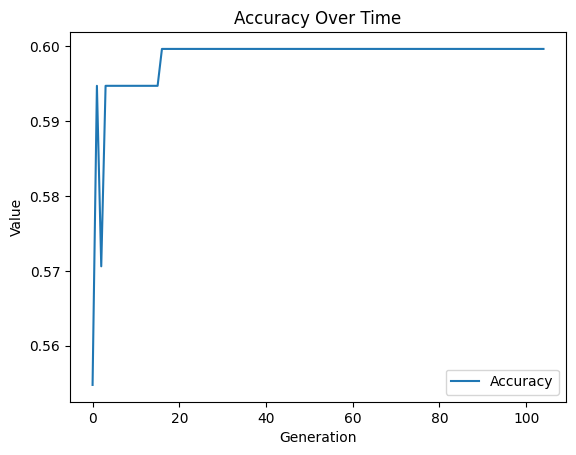

In [1]:
import json
import matplotlib.pyplot as plt

accs = []
evs = []
prompt1 = ''
prompt2 = ''

with open(f"out_element/0701_0331/generation_results.json", 'r') as f:
    content = f.readlines()
    for line in content:
        result = json.loads(line)
        acc = result['best_fitness']
        accs.append(acc)


print(accs)

plt.plot(accs, label='Accuracy')

plt.title('Accuracy Over Time')  # 添加標題
plt.xlabel('Generation')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()  # 顯示圖例

plt.show()

## 計算使用的費用

In [2]:
import json

input_token = 0
output_token = 0
for i in range(348):
    with open(f"out_element/0701_0331/{i+1}.json", 'r') as f:
        data = json.load(f)
        output_data = data["output_data"]

        for date_str, result in output_data.items():
            input_token += result["token"]["input_tokens"]
            output_token += result["token"]["output_tokens"]
        # print(input_token, output_token)

print(f'token: input {input_token}, output {output_token}')
print(f'預估費用 {(input_token/1000000)*0.35 + (output_token/1000000)*0.7} USD, {((input_token/1000000)*0.35 + (output_token/1000000)*0.7)*32.6} TWD')

token: input 23782104, output 10186870
預估費用 15.4545454 USD, 503.81818004 TWD
